# ECS 171 Group Project Team 9

## Introduction

Heart disease is one of the leading causes of death worldwide. Early prediction of heart disease risk can support timely medical intervention and lifestyle changes. The goal of this project is to develop and evaluate machine learning models that predict whether a patient is at risk of heart disease based on clinical and demographic attributes.

This is formulated as a binary classification problem, where the output indicates the presence or absence of heart disease.

## Dataset Description

Dataset: UCI Heart Disease Dataset

Size: ~300 instances
Attributes: ~13 features
Target variable: Presence of heart disease (0 = No, 1 = Yes)

## Exploratory Data Analysis (EDA)

### Data Input

In [122]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print(heart_disease.metadata)
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [123]:
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [124]:
y.head()

,num
0,0
1,2
2,1
3,0
4,0


### Data Cleaning

#### Finding Missing Values and Replace it with NaN

In [125]:
import numpy as np
import pandas as pd

X = X.replace('?', np.nan)
X.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

#### Turning Data Types to Numeric

In [126]:
num_cols = ['age','trestbps','chol','thalach','oldpeak','ca']
X[num_cols] = X[num_cols].apply(pd.to_numeric)

cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']
X[cat_cols] = X[cat_cols].apply(pd.to_numeric)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


#### Turn NaN into numbers

In [127]:
X['ca'] = X['ca'].fillna(X['ca'].median())
X['thal'] = X['thal'].fillna(X['thal'].mode()[0])

X.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

#### Outlier Detection

In [128]:
def detect_outliers(df, columns):
    outlier_indices = []
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)].index
        outlier_indices.extend(outliers)

    return list(set(outlier_indices))


In [129]:
outlier_cols = ['age','trestbps','chol','thalach','oldpeak']
outliers = detect_outliers(X, outlier_cols)

len(outliers)

19

#### Cap Outlier

In [130]:
def cap_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])
        
    return df

X = cap_outliers(X, outlier_cols)

#### Change Target Value from severity of hear disease to if the patient has heart disease or not

In [131]:
y = (y['num'] > 0).astype(int)

In [132]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: num, dtype: int32

#### Encode Categorical Variables - One-Hot Encoding

Ex. If a patient has: cp = 3   (non-anginal pain)

it becomes:
cp_2	cp_3	cp_4
0	1	0

Meaning:

The patient is not type 2

The patient is type 3

The patient is not type 4

In [133]:
X = pd.get_dummies(X, columns=['cp','restecg','slope','thal'], drop_first=True)
X.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6.0,thal_7.0
0,63.0,1,145.0,233.0,1,150.0,0,2.3,0.0,False,False,False,False,True,False,True,True,False
1,67.0,1,160.0,286.0,0,108.0,1,1.5,3.0,False,False,True,False,True,True,False,False,False
2,67.0,1,120.0,229.0,0,129.0,1,2.6,2.0,False,False,True,False,True,True,False,False,True
3,37.0,1,130.0,250.0,0,187.0,0,3.5,0.0,False,True,False,False,False,False,True,False,False
4,41.0,0,130.0,204.0,0,172.0,0,1.4,0.0,True,False,False,False,True,False,False,False,False


In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/heart_disease_clean.csv")

X = df.drop('target', axis=1)
y = df['target']

In [2]:
df.shape

(303, 19)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        303 non-null    int64
 1   sex        303 non-null    int64
 2   trestbps   303 non-null    int64
 3   chol       303 non-null    int64
 4   fbs        303 non-null    int64
 5   thalach    303 non-null    int64
 6   exang      303 non-null    int64
 7   oldpeak    303 non-null    int64
 8   ca         303 non-null    int64
 9   cp_2       303 non-null    int64
 10  cp_3       303 non-null    int64
 11  cp_4       303 non-null    int64
 12  restecg_1  303 non-null    int64
 13  restecg_2  303 non-null    int64
 14  slope_2    303 non-null    int64
 15  slope_3    303 non-null    int64
 16  thal_6.0   303 non-null    int64
 17  thal_7.0   303 non-null    int64
 18  target     303 non-null    int64
dtypes: int64(19)
memory usage: 45.1 KB


In [4]:
df.describe()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6.0,thal_7.0,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,131.346535,245.584158,0.148515,149.650165,0.326733,0.755776,0.663366,0.165017,0.283828,0.475248,0.013201,0.488449,0.462046,0.069307,0.059406,0.386139,0.458746
std,9.038662,0.467299,16.648749,47.558803,0.356198,22.738866,0.469794,1.032465,0.934375,0.371809,0.451600,0.500213,0.114325,0.500693,0.499382,0.254395,0.236774,0.487668,0.499120
min,29.000000,0.000000,94.000000,126.000000,0.000000,84.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,153.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,166.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,170.000000,371.000000,1.000000,202.000000,1.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Heart Disease vs No Heart Disease

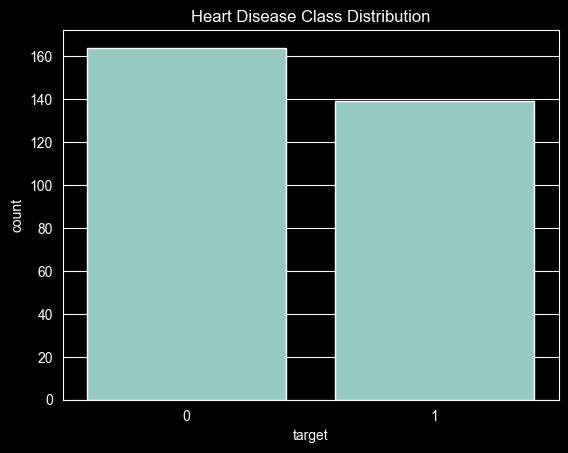

In [5]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Class Distribution")
plt.show()

In [6]:
df['target'].value_counts(normalize=True)

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

#### Medical Variable Distribution

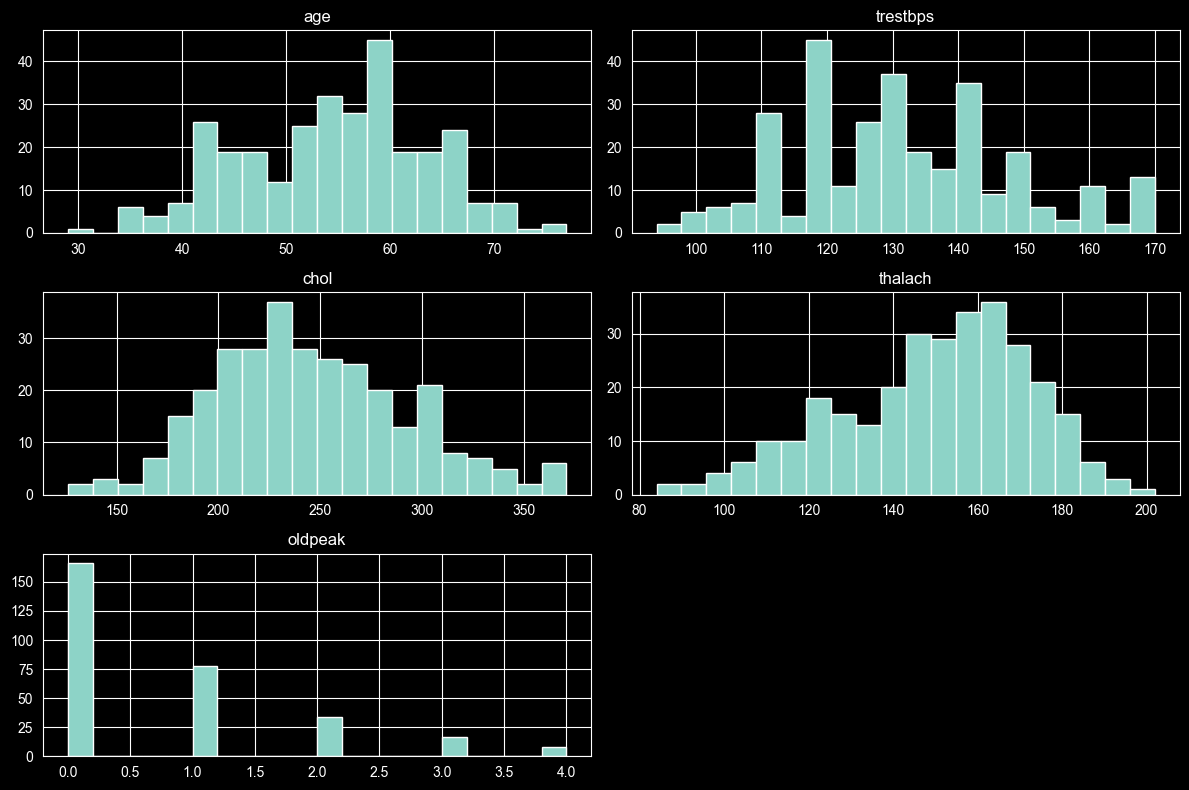

In [7]:
num_cols = ['age','trestbps','chol','thalach','oldpeak']

df[num_cols].hist(figsize=(12,8), bins=20,)
plt.tight_layout()
plt.show()


#### Boxplots for Age, Chol, Oldpeak, Trestbps vs Target

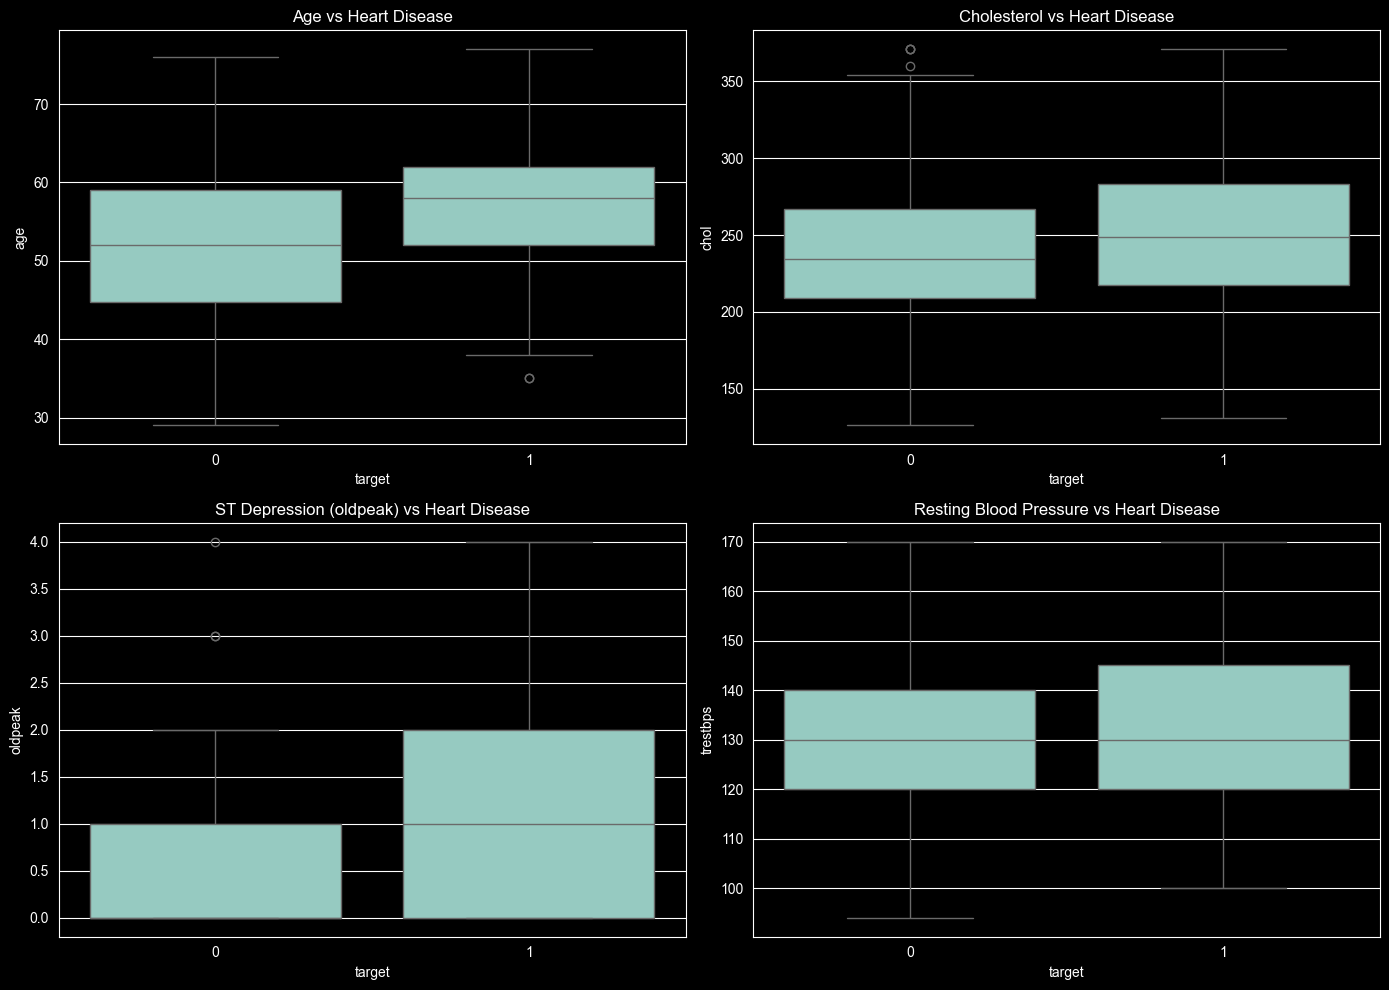

In [8]:
plt.figure(figsize=(14,10))

# 1
plt.subplot(2,2,1)
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")

# 2
plt.subplot(2,2,2)
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol vs Heart Disease")

# 3
plt.subplot(2,2,3)
sns.boxplot(x='target', y='oldpeak', data=df)
plt.title("ST Depression (oldpeak) vs Heart Disease")

# 4
plt.subplot(2,2,4)
sns.boxplot(x='target', y='trestbps', data=df)
plt.title("Resting Blood Pressure vs Heart Disease")

plt.tight_layout()
plt.show()


#### Countmap for All Categorical Features

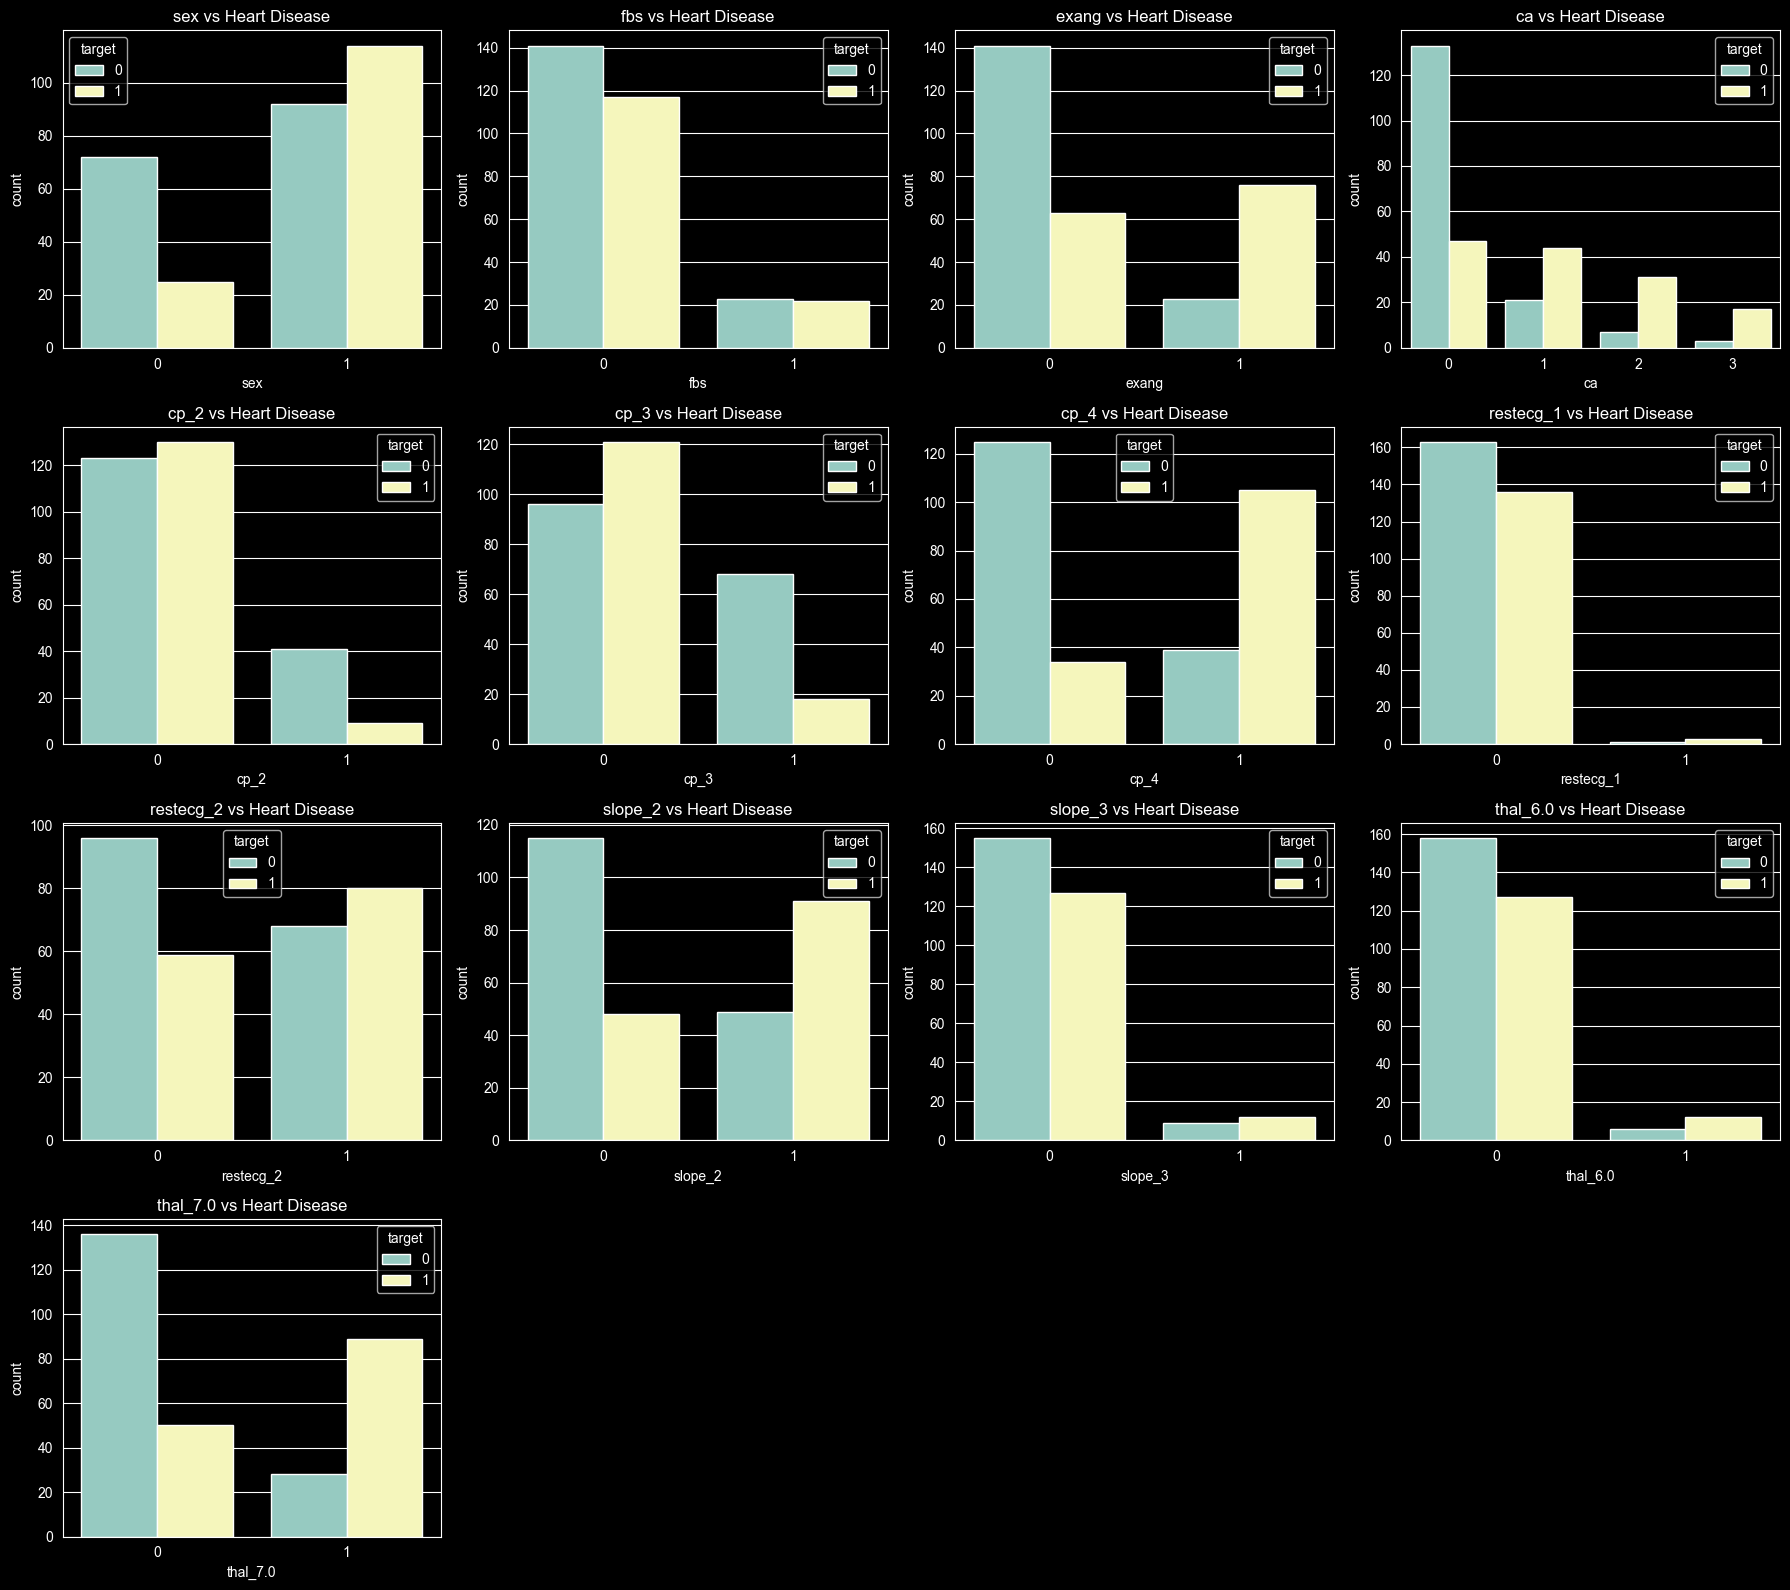

In [9]:
cat_cols = [
    'sex','fbs','exang','ca',
    'cp_2','cp_3','cp_4',
    'restecg_1','restecg_2',
    'slope_2','slope_3',
    'thal_6.0','thal_7.0'
]


plt.figure(figsize=(18,16))

for i, col in enumerate(cat_cols):
    plt.subplot(4,4,i+1)
    sns.countplot(x=df[col], hue=df['target'])
    plt.title(f"{col} vs Heart Disease")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


#### Correlation Heatmap

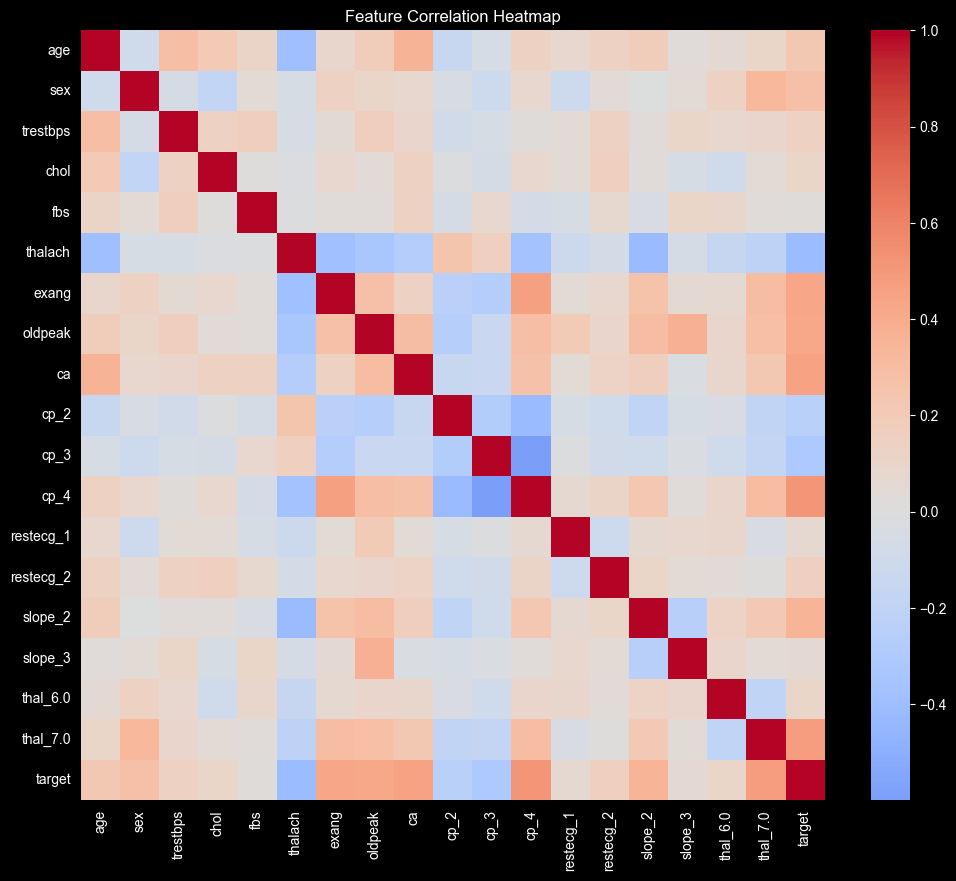

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


#### Pairmaps for Medical Features

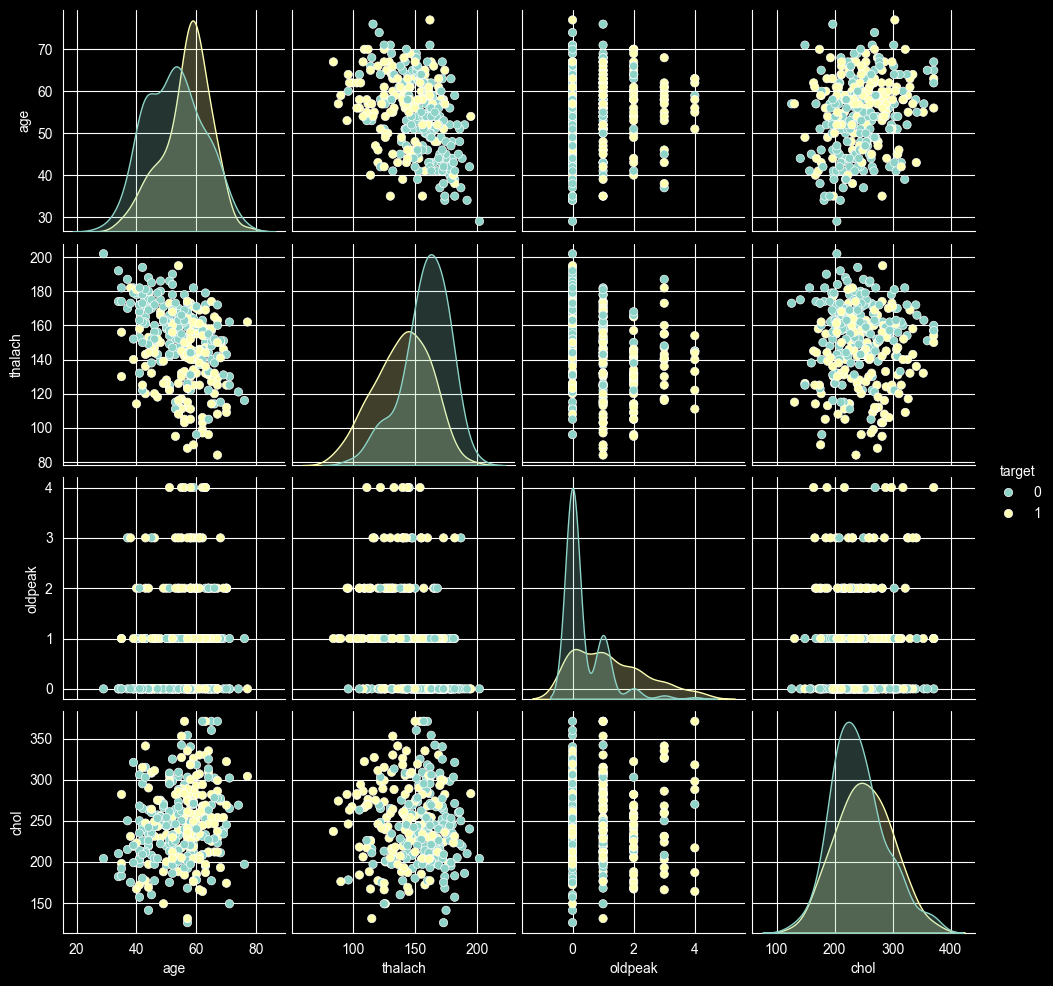

In [11]:
sns.pairplot(df[['age','thalach','oldpeak','chol','target']], hue='target')


#### Feature Selection

In [12]:
# ranking features by their correlation with the target
correlations = df.corr()['target'].sort_values(ascending=False)
print(correlations)

target       1.000000
cp_4         0.516459
thal_7.0     0.480582
ca           0.460033
exang        0.431894
oldpeak      0.423750
slope_2      0.355709
sex          0.276816
age          0.223120
restecg_2    0.160400
trestbps     0.144980
thal_6.0     0.104864
chol         0.103896
restecg_1    0.067605
slope_3      0.061710
fbs          0.025264
cp_2        -0.248683
cp_3        -0.315141
thalach     -0.417612
Name: target, dtype: float64


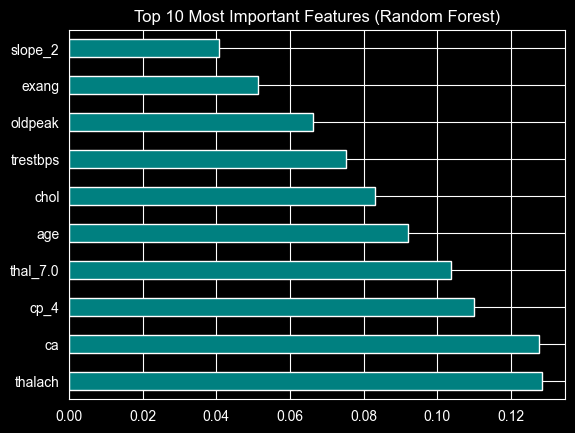

In [13]:
from sklearn.ensemble import RandomForestClassifier

# init and fit
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# visualizing importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()

In [14]:
from sklearn.feature_selection import mutual_info_classif

importances = mutual_info_classif(X, y)
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df.sort_values(by='Importance', ascending=False, inplace=True)
print(feat_df)

      Feature  Importance
11       cp_4    0.145299
6       exang    0.101580
10       cp_3    0.100871
17   thal_7.0    0.095639
8          ca    0.092814
15    slope_3    0.082837
9        cp_2    0.075579
3        chol    0.074440
14    slope_2    0.063570
7     oldpeak    0.062215
5     thalach    0.057551
16   thal_6.0    0.042627
12  restecg_1    0.032627
1         sex    0.024101
0         age    0.018594
13  restecg_2    0.001599
2    trestbps    0.000208
4         fbs    0.000000


The top three features appear to be ca (number of major vessels colored by flourosopy), cp (chest pain type) and thal_7.0 (thallium heart scan result).

#### Visualization of the Decision Space

In [15]:
import plotly.express as px

# Visualizing your top 3 features
fig = px.scatter_3d(df, x='ca', y='cp_4', z='thal_7.0',
              color='target', opacity=0.7,
              title="3D Feature Space: CA vs CP vs THAL")
fig.show()

#### Pair Plot

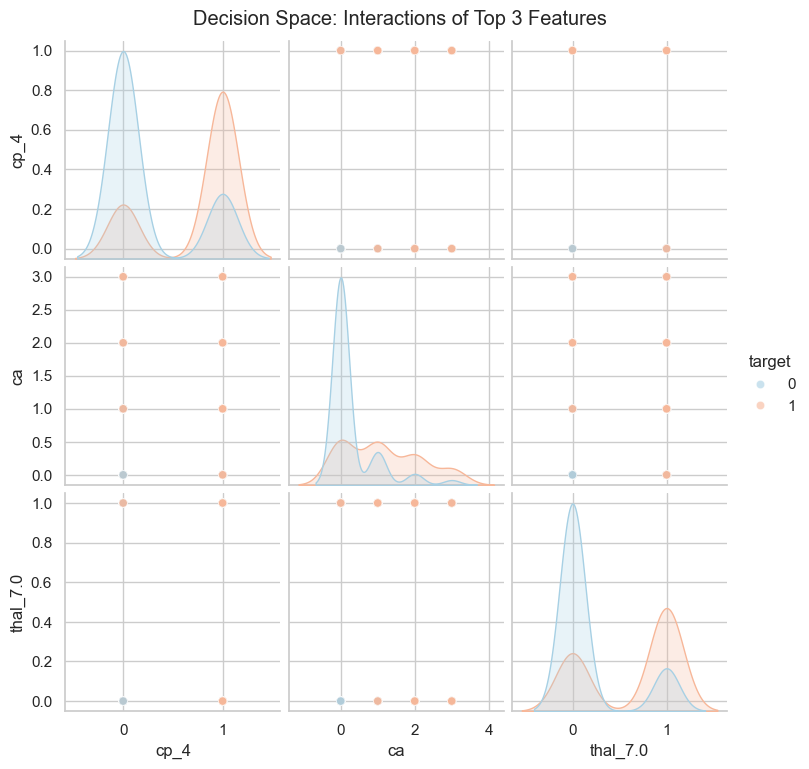

In [16]:
# combining selected features and target for plotting
plot_df = X[['cp_4', 'ca', 'thal_7.0']].copy()
plot_df['target'] = y

# creating the pair plot
sns.set_theme(style="whitegrid")
g = sns.pairplot(plot_df, hue='target', palette='RdBu_r',
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle("Decision Space: Interactions of Top 3 Features", y=1.02)
plt.show()

#### Strip Plot for ca

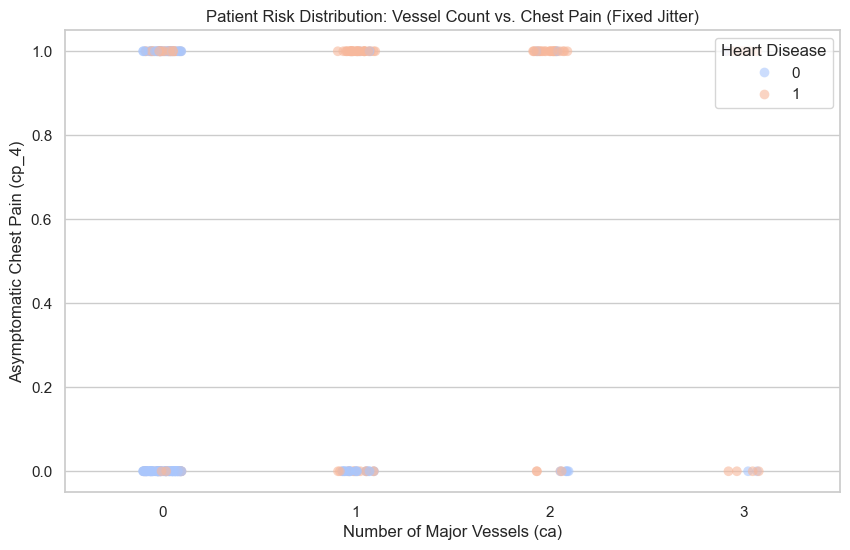

In [18]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='ca', y='cp_4', hue='target', data=plot_df,
              palette='coolwarm', jitter=True, alpha=0.6, size=7)

plt.title('Patient Risk Distribution: Vessel Count vs. Chest Pain (Fixed Jitter)')
plt.xlabel('Number of Major Vessels (ca)')
plt.ylabel('Asymptomatic Chest Pain (cp_4)')
plt.legend(title='Heart Disease', loc='upper right')
plt.show()